<a href="https://colab.research.google.com/github/camiloascencio-hash/GP-S/blob/main/E1_OFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#esto es una preueba
!git clone https://github.com/camiloascencio-hash/GP-S.git

import pandas as pd
import numpy as np
import json

Cloning into 'GP-S'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 34 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 48.82 KiB | 684.00 KiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
with open("GP-S/datos/metadatos.json", "r", encoding="utf-8") as archivo:
    metadatos = json.load(archivo)

metadatos

{'empresa': 'Bebidas del Maipo S.A.',
 'semilla': 20260923,
 'n_semanas_historia': 156,
 'fin_historia': '2026-09-21',
 'horizonte_planificacion': 13,
 'semana_focal_secuenciamiento': 12,
 'fecha_semana_focal': '2026-12-14',
 'n_sku': 9,
 'familias': ['CIT', 'FUN', 'NEC']}

In [ ]:
def leer(nombre_archivo):
    return pd.read_csv("GP-S/datos/" + nombre_archivo)

llen_raw = leer("calidad_llenado.csv")
atr_raw = leer("calidad_atributos.csv")
spec = leer("especificaciones_calidad.csv")
maestro = leer("maestro_sku.csv")
dem_raw = leer("demanda_semanal.csv")

In [ ]:
for nombre, d in [("calidad_llenado", llen_raw), ("calidad_atributos", atr_raw),
                  ("especificaciones", spec), ("maestro_sku", maestro),
                  ("demanda_semanal", dem_raw)]:
    print(nombre, d.shape[0], "filas x", d.shape[1], "columnas")

# los datos crudos no se modifican: se trabaja sobre copias
llen = llen_raw.copy()
atr = atr_raw.copy()
dem = dem_raw.copy()

calidad_llenado 4200 filas x 10 columnas
calidad_atributos 210 filas x 8 columnas
especificaciones 3 filas x 6 columnas
maestro_sku 9 filas x 13 columnas
demanda_semanal 1404 filas x 10 columnas


In [ ]:
llen.head()

,subgrupo,fecha,semana_registro,turno,linea,sku,formato_L,hora,n_obs,volumen_mL
0,1,2026-07-20,1,A (06-14),L1,FUN-B05,0.5,06:00,1,500.86
1,1,2026-07-20,1,A (06-14),L1,FUN-B05,0.5,06:00,2,502.11
2,1,2026-07-20,1,A (06-14),L1,FUN-B05,0.5,06:00,3,503.12
3,1,2026-07-20,1,A (06-14),L1,FUN-B05,0.5,06:00,4,502.60
4,1,2026-07-20,1,A (06-14),L1,FUN-B05,0.5,06:00,5,499.11


In [ ]:
atr.head()

,fecha,semana_registro,turno,linea,sku,n_inspeccionadas,n_defectuosas,causa_principal
0,2026-07-20,1,A (06-14),L1,FUN-B05,238,1,Envase deformado
1,2026-07-20,1,B (14-22),L1,CIT-L05,182,3,Etiqueta
2,2026-07-21,1,A (06-14),L1,NEC-D05,190,4,Envase deformado
3,2026-07-21,1,B (14-22),L1,CIT-L05,194,3,Nivel de llenado
4,2026-07-22,1,A (06-14),L1,CIT-L05,190,8,Etiqueta


In [ ]:
spec

,formato_L,nominal_mL,LIE_mL,LSE_mL,tolerancia_oiml_mL,limite_legal_inferior_mL
0,0.5,500.0,492.0,508.0,15.0,485.0
1,1.5,1500.0,1485.0,1515.0,22.5,1477.5
2,3.0,3000.0,2975.0,3025.0,45.0,2955.0


In [ ]:
bitacora = []

def registrar(archivo, chequeo, resultado, decision):
    bitacora.append({"archivo": archivo, "chequeo": chequeo,
                     "resultado": resultado, "decision": decision})

In [ ]:
faltantes = llen.isna().sum().sum()
registrar("calidad_llenado", "Valores faltantes", str(faltantes) + " celdas vacías", "Sin acción")

duplicados = llen.duplicated(["subgrupo", "n_obs"]).sum()
registrar("calidad_llenado", "Duplicados (subgrupo, n_obs)", str(duplicados) + " duplicados", "Sin acción")

tam = llen.groupby("subgrupo").size()
tamanos = [int(v) for v in sorted(tam.unique())]
registrar("calidad_llenado", "Tamaño de subgrupo",
          "n = " + str(tamanos) + " en " + str(len(tam)) + " subgrupos",
          "n = 5 constante, se usan las constantes de la carta X-R")

mezclas = llen.groupby("subgrupo")[["linea", "sku", "turno"]].nunique().max().max()
registrar("calidad_llenado", "Subgrupos que mezclan línea, SKU o turno",
          "máximo " + str(mezclas) + " valor distinto por subgrupo",
          "Sin acción, los subgrupos son racionales")

imposibles = (llen["volumen_mL"] <= 0).sum()
registrar("calidad_llenado", "Volúmenes menores o iguales a cero", str(imposibles) + " valores", "Sin acción")

cuenta = llen.groupby(["linea", "formato_L", "turno"])["subgrupo"].nunique()
registrar("calidad_llenado", "Subgrupos por línea, formato y turno",
          "mínimo " + str(cuenta.min()) + ", máximo " + str(cuenta.max()),
          "Se reporta el desbalance (turno B de 1,5 L tiene menos subgrupos)")

In [ ]:
faltantes_atr = atr.isna().sum().sum()
registrar("calidad_atributos", "Valores faltantes", str(faltantes_atr) + " celdas vacías", "Sin acción")

duplicados_atr = atr.duplicated().sum()
registrar("calidad_atributos", "Filas duplicadas", str(duplicados_atr) + " duplicados", "Sin acción")

mal = (atr["n_defectuosas"] > atr["n_inspeccionadas"]).sum()
registrar("calidad_atributos", "Defectuosas mayores que inspeccionadas", str(mal) + " filas", "Sin acción")

registrar("calidad_atributos", "Tamaño de inspección n",
          "entre " + str(atr["n_inspeccionadas"].min()) + " y " + str(atr["n_inspeccionadas"].max()),
          "n varía, se usa carta p con límites variables")

sin_def = (atr["causa_principal"] == "Sin defectos").sum()
registrar("calidad_atributos", "Categoría 'Sin defectos'", str(sin_def) + " filas",
          "Se mantienen para calcular p, se excluyen del Pareto")

In [ ]:
registrar("especificaciones_calidad", "Valores faltantes", str(spec.isna().sum().sum()) + " celdas vacías", "Sin acción")
registrar("maestro_sku", "Valores faltantes", str(maestro.isna().sum().sum()) + " celdas vacías", "Sin acción")

faltantes_dem = dem.isna().sum().sum()
registrar("demanda_semanal", "Valores faltantes",
          str(faltantes_dem) + " celdas vacías (ventas_cajas y dias_sin_stock)",
          "Se revisan las filas; el tratamiento se define en la Parte B")

duplicados_dem = dem.duplicated().sum()
registrar("demanda_semanal", "Filas duplicadas", str(duplicados_dem) + " duplicados", "Sin acción")

In [ ]:
# las filas con datos faltantes en demanda
dem[dem.isna().any(axis=1)]

,semana,fecha_lunes,anio_iso,semana_iso,sku,ventas_cajas,dias_sin_stock,promocion,precio_lista_clp,precio_efectivo_clp
724,101,2025-09-01,2025,36,CIT-L15,NaN,NaN,0,7980,7980
725,102,2025-09-08,2025,37,CIT-L15,NaN,NaN,1,7980,6433
726,103,2025-09-15,2025,38,CIT-L15,NaN,NaN,0,7980,7980


In [ ]:
bit_df = pd.DataFrame(bitacora)
bit_df

,archivo,chequeo,resultado,decision
0,calidad_llenado,Valores faltantes,0 celdas vacías,Sin acción
1,calidad_llenado,"Duplicados (subgrupo, n_obs)",0 duplicados,Sin acción
2,calidad_llenado,Tamaño de subgrupo,n = [5] en 840 subgrupos,"n = 5 constante, se usan las constantes de la ..."
3,calidad_llenado,"Subgrupos que mezclan línea, SKU o turno",máximo 1 valor distinto por subgrupo,"Sin acción, los subgrupos son racionales"
4,calidad_llenado,Volúmenes menores o iguales a cero,0 valores,Sin acción
5,calidad_llenado,"Subgrupos por línea, formato y turno","mínimo 76, máximo 124","Se reporta el desbalance (turno B de 1,5 L tie..."
6,calidad_atributos,Valores faltantes,0 celdas vacías,Sin acción
7,calidad_atributos,Filas duplicadas,0 duplicados,Sin acción
8,calidad_atributos,Defectuosas mayores que inspeccionadas,0 filas,Sin acción
9,calidad_atributos,Tamaño de inspección n,entre 181 y 260,"n varía, se usa carta p con límites variables"


In [ ]:
### Estado de los datos

#Los archivos de calidad (llenado y atributos) están completos: sin faltantes, sin duplicados y sin valores imposibles. Los 840 subgrupos de llenado tienen n = 5 y cada uno corresponde a una sola línea, SKU y turno.

#Hallazgos a documentar:
#- Los subgrupos por turno están desbalanceados (turno B de 1,5 L tiene 76, contra 104-108 de los otros turnos).
#- En calidad_atributos el tamaño de inspección varía (181 a 260), por lo que corresponde carta p. Hay 2 filas con causa "Sin defectos".
#- demanda_semanal tiene 3 filas con ventas_cajas y dias_sin_stock faltantes. Se tratarán en la Parte B.

In [ ]:
g = llen.groupby("subgrupo")

sg = g.agg(fecha=("fecha", "first"), hora=("hora", "first"),
           semana=("semana_registro", "first"), turno=("turno", "first"),
           linea=("linea", "first"), formato=("formato_L", "first"),
           sku=("sku", "first"))

sg["xbar"] = g["volumen_mL"].mean()
sg["R"] = g["volumen_mL"].max() - g["volumen_mL"].min()
sg = sg.reset_index()

# el orden en el tiempo sale de fecha y hora (el número de subgrupo no sirve en L2)
sg["fecha_hora"] = pd.to_datetime(sg["fecha"] + " " + sg["hora"])

sg.head()

,subgrupo,fecha,hora,semana,turno,linea,formato,sku,xbar,R,fecha_hora
0,1,2026-07-20,06:00,1,A (06-14),L1,0.5,FUN-B05,501.560,4.01,2026-07-20 06:00:00
1,2,2026-07-20,08:00,1,A (06-14),L1,0.5,FUN-B05,501.752,5.17,2026-07-20 08:00:00
2,3,2026-07-20,10:00,1,A (06-14),L1,0.5,FUN-B05,503.630,4.13,2026-07-20 10:00:00
3,4,2026-07-20,12:00,1,A (06-14),L1,0.5,FUN-B05,503.172,2.10,2026-07-20 12:00:00
4,5,2026-07-20,14:00,1,B (14-22),L1,0.5,CIT-L05,503.396,8.49,2026-07-20 14:00:00


In [ ]:
# Todos los subgrupos tienen n = 5, por lo que corresponde la carta X-R y no la X-S
A2 = 0.577
D3 = 0
D4 = 2.114
d2 = 2.326

resumen = []

In [ ]:
linea = "L1"
formato = 0.5

c = sg[(sg["linea"] == linea) & (sg["formato"] == formato)]
c = c.sort_values("fecha_hora").reset_index(drop=True)
c["orden"] = c.index + 1

f1 = c[c["semana"] <= 5]      # Fase I: se calculan los límites
f2 = c[c["semana"] > 5]       # Fase II: se juzga contra los límites congelados

len(f1), len(f2)

(120, 120)

In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 1:", len(fuera), "puntos fuera")

# se sacan los puntos fuera para recalcular
f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 1: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 2:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 2: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 3:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 3: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb
LCIr = D3 * Rb
sigma = Rb / d2

print("x doble barra:", round(xbb, 2), " R barra:", round(Rb, 2), " sigma:", round(sigma, 3))
print("LCS X:", round(LCSx, 2), " LCI X:", round(LCIx, 2), " LCS R:", round(LCSr, 2))

# puntos de Fase I que quedaron fuera del cálculo
fase1_completa = c[c["semana"] <= 5]
excluidos = fase1_completa[fase1_completa["orden"].isin(f1["orden"]) == False]

excluidos[["orden", "fecha_hora", "turno", "sku", "xbar", "R"]]

x doble barra: 502.47  R barra: 4.86  sigma: 2.091
LCS X: 505.27  LCI X: 499.66  LCS R: 10.28


,orden,fecha_hora,turno,sku,xbar,R


In [ ]:
c["fuera_x"] = (c["xbar"] > LCSx) | (c["xbar"] < LCIx)
c["fuera_r"] = (c["R"] > LCSr) | (c["R"] < LCIr)

f2 = c[c["semana"] > 5]

print("Fase II, puntos fuera en X:", f2["fuera_x"].sum(), "de", len(f2))
print("Fase II, puntos fuera en R:", f2["fuera_r"].sum(), "de", len(f2))

resumen.append([linea, formato, len(fase1_completa), len(excluidos),
                xbb, Rb, LCSx, LCIx, LCSr, sigma,
                f2["fuera_x"].sum(), f2["fuera_r"].sum()])

Fase II, puntos fuera en X: 91 de 120
Fase II, puntos fuera en R: 0 de 120


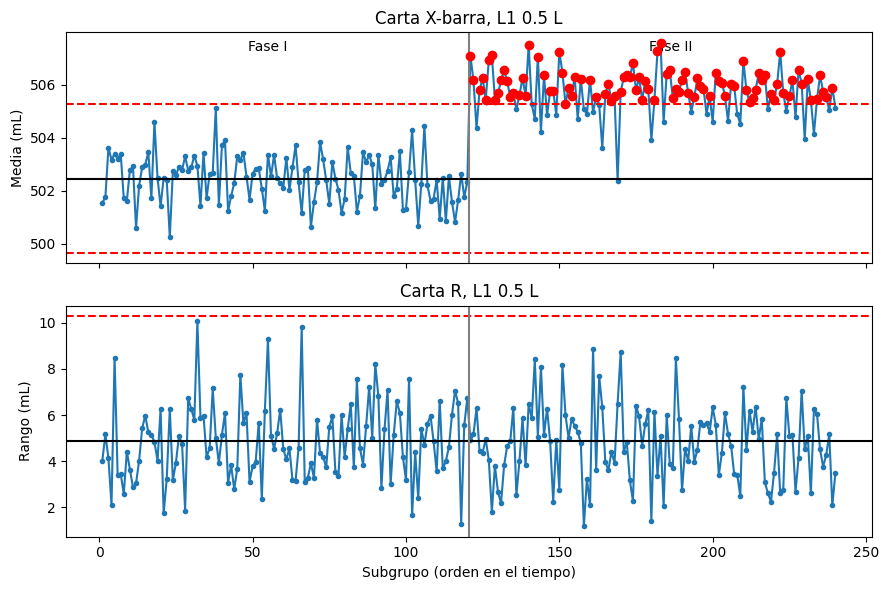

In [ ]:
import matplotlib.pyplot as plt

corte = c.loc[c["semana"] <= 5, "orden"].max() + 0.5

fuera_x = c[c["fuera_x"]]
fuera_r = c[c["fuera_r"]]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Carta X-barra
ax[0].plot(c["orden"], c["xbar"], "o-", markersize=3)
ax[0].axhline(xbb, color="black")
ax[0].axhline(LCSx, color="red", linestyle="--")
ax[0].axhline(LCIx, color="red", linestyle="--")
ax[0].axvline(corte, color="gray")
ax[0].scatter(fuera_x["orden"], fuera_x["xbar"], color="red", zorder=5)
ax[0].text(0.25, 0.92, "Fase I", transform=ax[0].transAxes, ha="center")
ax[0].text(0.75, 0.92, "Fase II", transform=ax[0].transAxes, ha="center")
ax[0].set(ylabel="Media (mL)", title="Carta X-barra, " + linea + " " + str(formato) + " L")

# Carta R
ax[1].plot(c["orden"], c["R"], "o-", markersize=3)
ax[1].axhline(Rb, color="black")
ax[1].axhline(LCSr, color="red", linestyle="--")
ax[1].axvline(corte, color="gray")
ax[1].scatter(fuera_r["orden"], fuera_r["R"], color="red", zorder=5)
ax[1].set(xlabel="Subgrupo (orden en el tiempo)", ylabel="Rango (mL)",
          title="Carta R, " + linea + " " + str(formato) + " L")

plt.tight_layout()
plt.show()

In [ ]:
linea = "L2"
formato = 1.5

c = sg[(sg["linea"] == linea) & (sg["formato"] == formato)]
c = c.sort_values("fecha_hora").reset_index(drop=True)
c["orden"] = c.index + 1

f1 = c[c["semana"] <= 5]      # Fase I: se calculan los límites
f2 = c[c["semana"] > 5]       # Fase II: se juzga contra los límites congelados

len(f1), len(f2)

(136, 152)

In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 1:", len(fuera), "puntos fuera")

# se sacan los puntos fuera para recalcular
f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 1: 5 puntos fuera


,orden,turno,sku,xbar,R
3,4,C (22-06),NEC-D15,1505.642,25.95
31,32,C (22-06),NEC-D15,1513.752,9.26
72,73,C (22-06),FUN-B15,1510.648,27.57
74,75,C (22-06),FUN-B15,1508.444,26.43
79,80,C (22-06),FUN-B15,1510.722,28.13


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 2:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 2: 1 puntos fuera


,orden,turno,sku,xbar,R
81,82,C (22-06),NEC-D15,1511.316,13.43


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 3:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 3: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb
LCIr = D3 * Rb
sigma = Rb / d2

print("x doble barra:", round(xbb, 2), " R barra:", round(Rb, 2), " sigma:", round(sigma, 3))
print("LCS X:", round(LCSx, 2), " LCI X:", round(LCIx, 2), " LCS R:", round(LCSr, 2))

# puntos de Fase I que quedaron fuera del cálculo
fase1_completa = c[c["semana"] <= 5]
excluidos = fase1_completa[fase1_completa["orden"].isin(f1["orden"]) == False]

excluidos[["orden", "fecha_hora", "turno", "sku", "xbar", "R"]]

x doble barra: 1504.3  R barra: 11.56  sigma: 4.97
LCS X: 1510.97  LCI X: 1497.63  LCS R: 24.44


,orden,fecha_hora,turno,sku,xbar,R
3,4,2026-07-20 22:00:00,C (22-06),NEC-D15,1505.642,25.95
31,32,2026-07-28 22:00:00,C (22-06),NEC-D15,1513.752,9.26
72,73,2026-08-07 00:00:00,C (22-06),FUN-B15,1510.648,27.57
74,75,2026-08-07 04:00:00,C (22-06),FUN-B15,1508.444,26.43
79,80,2026-08-07 22:00:00,C (22-06),FUN-B15,1510.722,28.13
81,82,2026-08-10 02:00:00,C (22-06),NEC-D15,1511.316,13.43


In [ ]:
c["fuera_x"] = (c["xbar"] > LCSx) | (c["xbar"] < LCIx)
c["fuera_r"] = (c["R"] > LCSr) | (c["R"] < LCIr)

f2 = c[c["semana"] > 5]

print("Fase II, puntos fuera en X:", f2["fuera_x"].sum(), "de", len(f2))
print("Fase II, puntos fuera en R:", f2["fuera_r"].sum(), "de", len(f2))

resumen.append([linea, formato, len(fase1_completa), len(excluidos),
                xbb, Rb, LCSx, LCIx, LCSr, sigma,
                f2["fuera_x"].sum(), f2["fuera_r"].sum()])

Fase II, puntos fuera en X: 6 de 152
Fase II, puntos fuera en R: 4 de 152


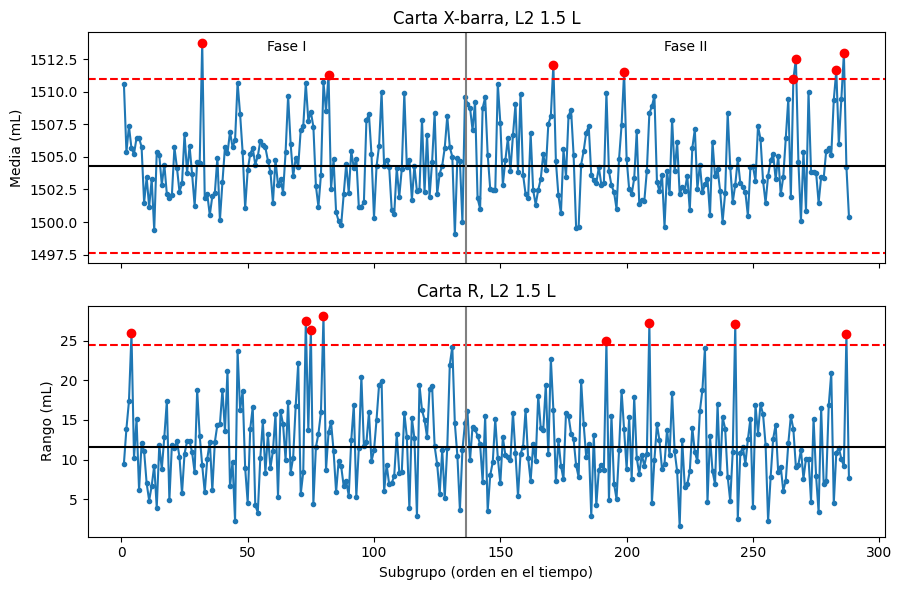

In [ ]:
corte = c.loc[c["semana"] <= 5, "orden"].max() + 0.5

fuera_x = c[c["fuera_x"]]
fuera_r = c[c["fuera_r"]]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Carta X-barra
ax[0].plot(c["orden"], c["xbar"], "o-", markersize=3)
ax[0].axhline(xbb, color="black")
ax[0].axhline(LCSx, color="red", linestyle="--")
ax[0].axhline(LCIx, color="red", linestyle="--")
ax[0].axvline(corte, color="gray")
ax[0].scatter(fuera_x["orden"], fuera_x["xbar"], color="red", zorder=5)
ax[0].text(0.25, 0.92, "Fase I", transform=ax[0].transAxes, ha="center")
ax[0].text(0.75, 0.92, "Fase II", transform=ax[0].transAxes, ha="center")
ax[0].set(ylabel="Media (mL)", title="Carta X-barra, " + linea + " " + str(formato) + " L")

# Carta R
ax[1].plot(c["orden"], c["R"], "o-", markersize=3)
ax[1].axhline(Rb, color="black")
ax[1].axhline(LCSr, color="red", linestyle="--")
ax[1].axvline(corte, color="gray")
ax[1].scatter(fuera_r["orden"], fuera_r["R"], color="red", zorder=5)
ax[1].set(xlabel="Subgrupo (orden en el tiempo)", ylabel="Rango (mL)",
          title="Carta R, " + linea + " " + str(formato) + " L")

plt.tight_layout()
plt.show()

In [ ]:
linea = "L2"
formato = 3.0

c = sg[(sg["linea"] == linea) & (sg["formato"] == formato)]
c = c.sort_values("fecha_hora").reset_index(drop=True)
c["orden"] = c.index + 1

f1 = c[c["semana"] <= 5]      # Fase I: se calculan los límites
f2 = c[c["semana"] > 5]       # Fase II: se juzga contra los límites congelados

len(f1), len(f2)

(164, 148)

In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 1:", len(fuera), "puntos fuera")

# se sacan los puntos fuera para recalcular
f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 1: 6 puntos fuera


,orden,turno,sku,xbar,R
23,24,C (22-06),FUN-B30,3023.588,21.08
69,70,C (22-06),FUN-B30,3010.470,43.43
102,103,C (22-06),FUN-B30,3021.058,20.58
141,142,C (22-06),NEC-D30,3005.366,43.67
150,151,B (14-22),CIT-L30,3008.436,42.19
153,154,C (22-06),CIT-L30,3010.112,51.49


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 2:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 2: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
xbb = f1["xbar"].mean()
Rb = f1["R"].mean()

LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb

fuera = f1[(f1["R"] > LCSr) | (f1["xbar"] > LCSx) | (f1["xbar"] < LCIx)]
print("Ronda 3:", len(fuera), "puntos fuera")

f1 = f1[(f1["R"] <= LCSr) & (f1["xbar"] <= LCSx) & (f1["xbar"] >= LCIx)]

fuera[["orden", "turno", "sku", "xbar", "R"]]

Ronda 3: 0 puntos fuera


,orden,turno,sku,xbar,R


In [ ]:
LCSx = xbb + A2 * Rb
LCIx = xbb - A2 * Rb
LCSr = D4 * Rb
LCIr = D3 * Rb
sigma = Rb / d2

print("x doble barra:", round(xbb, 2), " R barra:", round(Rb, 2), " sigma:", round(sigma, 3))
print("LCS X:", round(LCSx, 2), " LCI X:", round(LCIx, 2), " LCS R:", round(LCSr, 2))

# puntos de Fase I que quedaron fuera del cálculo
fase1_completa = c[c["semana"] <= 5]
excluidos = fase1_completa[fase1_completa["orden"].isin(f1["orden"]) == False]

excluidos[["orden", "fecha_hora", "turno", "sku", "xbar", "R"]]

x doble barra: 3008.73  R barra: 19.16  sigma: 8.237
LCS X: 3019.78  LCI X: 2997.67  LCS R: 40.5


,orden,fecha_hora,turno,sku,xbar,R
23,24,2026-07-22 22:00:00,C (22-06),FUN-B30,3023.588,21.08
69,70,2026-08-03 02:00:00,C (22-06),FUN-B30,3010.470,43.43
102,103,2026-08-11 04:00:00,C (22-06),FUN-B30,3021.058,20.58
141,142,2026-08-19 02:00:00,C (22-06),NEC-D30,3005.366,43.67
150,151,2026-08-19 20:00:00,B (14-22),CIT-L30,3008.436,42.19
153,154,2026-08-20 02:00:00,C (22-06),CIT-L30,3010.112,51.49


In [ ]:
c["fuera_x"] = (c["xbar"] > LCSx) | (c["xbar"] < LCIx)
c["fuera_r"] = (c["R"] > LCSr) | (c["R"] < LCIr)

f2 = c[c["semana"] > 5]

print("Fase II, puntos fuera en X:", f2["fuera_x"].sum(), "de", len(f2))
print("Fase II, puntos fuera en R:", f2["fuera_r"].sum(), "de", len(f2))

resumen.append([linea, formato, len(fase1_completa), len(excluidos),
                xbb, Rb, LCSx, LCIx, LCSr, sigma,
                f2["fuera_x"].sum(), f2["fuera_r"].sum()])

Fase II, puntos fuera en X: 0 de 148
Fase II, puntos fuera en R: 2 de 148


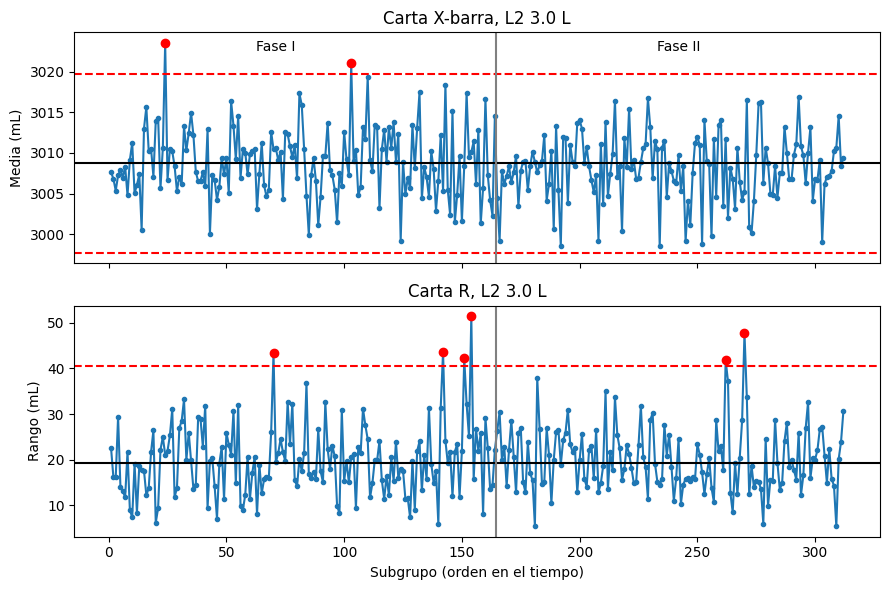

In [ ]:
corte = c.loc[c["semana"] <= 5, "orden"].max() + 0.5

fuera_x = c[c["fuera_x"]]
fuera_r = c[c["fuera_r"]]

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Carta X-barra
ax[0].plot(c["orden"], c["xbar"], "o-", markersize=3)
ax[0].axhline(xbb, color="black")
ax[0].axhline(LCSx, color="red", linestyle="--")
ax[0].axhline(LCIx, color="red", linestyle="--")
ax[0].axvline(corte, color="gray")
ax[0].scatter(fuera_x["orden"], fuera_x["xbar"], color="red", zorder=5)
ax[0].text(0.25, 0.92, "Fase I", transform=ax[0].transAxes, ha="center")
ax[0].text(0.75, 0.92, "Fase II", transform=ax[0].transAxes, ha="center")
ax[0].set(ylabel="Media (mL)", title="Carta X-barra, " + linea + " " + str(formato) + " L")

# Carta R
ax[1].plot(c["orden"], c["R"], "o-", markersize=3)
ax[1].axhline(Rb, color="black")
ax[1].axhline(LCSr, color="red", linestyle="--")
ax[1].axvline(corte, color="gray")
ax[1].scatter(fuera_r["orden"], fuera_r["R"], color="red", zorder=5)
ax[1].set(xlabel="Subgrupo (orden en el tiempo)", ylabel="Rango (mL)",
          title="Carta R, " + linea + " " + str(formato) + " L")

plt.tight_layout()
plt.show()

In [ ]:
columnas = ["linea", "formato", "n_fase1", "excluidos", "x_doble_barra", "R_barra",
            "LCS_x", "LCI_x", "LCS_R", "sigma", "fase2_fuera_x", "fase2_fuera_R"]

tabla = pd.DataFrame(resumen, columns=columnas).round(2)
tabla

,linea,formato,n_fase1,excluidos,x_doble_barra,R_barra,LCS_x,LCI_x,LCS_R,sigma,fase2_fuera_x,fase2_fuera_R
0,L1,0.5,120,0,502.47,4.86,505.27,499.66,10.28,2.09,91,0
1,L2,1.5,136,6,1504.30,11.56,1510.97,1497.63,24.44,4.97,6,4
2,L2,3.0,164,6,3008.73,19.16,3019.78,2997.67,40.50,8.24,0,2


In [ ]:
def reglas_we(x, cl, sig):
    """Devuelve DataFrame booleano con las reglas WE1-WE4 y tendencia (N-T)."""
    x = np.asarray(x, float); z = (x - cl) / sig; n = len(x)
    r = {k: np.zeros(n, bool) for k in ["WE1", "WE2", "WE3", "WE4", "N-T"]}
    for i in range(n):
        r["WE1"][i] = abs(z[i]) > 3
        if i >= 2:
            w = z[i-2:i+1]
            r["WE2"][i] = ((w > 2).sum() >= 2 and z[i] > 2) or ((w < -2).sum() >= 2 and z[i] < -2)
        if i >= 4:
            w = z[i-4:i+1]
            r["WE3"][i] = ((w > 1).sum() >= 4 and z[i] > 1) or ((w < -1).sum() >= 4 and z[i] < -1)
        if i >= 7:
            w = z[i-7:i+1]
            r["WE4"][i] = (w > 0).all() or (w < 0).all()
        if i >= 5:
            dif = np.diff(x[i-5:i+1])
            r["N-T"][i] = (dif > 0).all() or (dif < 0).all()
    return pd.DataFrame(r)

# Definimos de forma robusta las variables faltantes basadas en la tabla 'res'
CARTAS = []
LIM = {}
for _, fila in res.iterrows():
    nombre_carta = f"{fila['linea']} {fila['formato']} L"
    CARTAS.append(nombre_carta)
    LIM[nombre_carta] = {
        "xbb": fila["xbb"],
        "sigma_xbar": fila["sigma"] / np.sqrt(5),
        "LCS_R": fila["LCSr"],
        "Rb": fila["Rb"]
    }

# Añadimos la columna 'carta' y 'fase' al DataFrame global sg para poder procesarlo
sg["carta"] = sg["linea"] + " " + sg["formato"].astype(str) + " L"
sg["fase"] = np.where(sg["semana"] <= 5, "Fase I", "Fase II")

OUT_DIR = "." # Guardar en el directorio actual

partes = []
for c in CARTAS:
    g = sg[sg.carta == c].copy(); L = LIM[c]
    rx = reglas_we(g.xbar, L["xbb"], L["sigma_xbar"]).add_prefix("X_")
    # carta R: WE1 (sobre LCS_R) y WE4 (8 seguidos sobre R-barra)
    rR = pd.DataFrame({"R_WE1": (g.R > L["LCS_R"]).values,
                       "R_WE4": pd.Series((g.R > L["Rb"]).values).rolling(8).sum().eq(8).values})
    partes.append(pd.concat([g.reset_index(drop=True), rx, rR], axis=1))
sg = pd.concat(partes, ignore_index=True)
REGLAS_X = ["X_WE1", "X_WE2", "X_WE3", "X_WE4", "X_N-T"]; REGLAS_R = ["R_WE1", "R_WE4"]
sg["senal_X"] = sg[REGLAS_X].any(axis=1); sg["senal_R"] = sg[REGLAS_R].any(axis=1)
sg["senal"] = sg.senal_X | sg.senal_R

tabla_reglas = sg.groupby(["carta", "fase"])[REGLAS_X + REGLAS_R + ["senal"]].sum()
tabla_reglas["subgrupos"] = sg.groupby(["carta", "fase"]).size()
tabla_reglas["%_con_señal"] = 100 * tabla_reglas.senal / tabla_reglas.subgrupos
tabla_reglas.to_csv(f"{OUT_DIR}/senales_por_regla.csv")
tabla_reglas.round(1)

NameError: name 'CARTAS' is not defined

In [ ]:
# ---------- Reglas de Nelson sobre la carta X-barra (Fase II) ----------
# Las 4 reglas corresponden a los patrones de la lámina 19 de Calidad II:
#   R1: 1 punto fuera de 3 sigma             -> "punto extremo"
#   R2: 9 puntos seguidos al mismo lado      -> "varios puntos al mismo lado de la línea central"
#   R3: 6 puntos seguidos subiendo o bajando -> "tendencia sostenida"
#   R4: 14 puntos alternando arriba/abajo    -> "alternancia sistemática"

def reglas_nelson(x, lc, sigma):
    # x = medias de subgrupo en orden cronológico, lc = línea central, sigma = sigma de la MEDIA (sigma / raiz(n))
    x = np.asarray(x, float)
    z = (x - lc) / sigma
    n_ = len(x)
    out = {}
    out["R1: fuera de 3s"] = [i for i in range(n_) if abs(z[i]) > 3]
    out["R2: 9 en un lado"] = [
        i for i in range(8, n_)
        if all(z[i - k] > 0 for k in range(9)) or all(z[i - k] < 0 for k in range(9))]
    out["R3: 6 crecientes/decrecientes"] = [
        i for i in range(5, n_)
        if all(x[i - k] > x[i - k - 1] for k in range(5))
        or all(x[i - k] < x[i - k - 1] for k in range(5))]
    out["R4: 14 alternando"] = [
        i for i in range(13, n_)
        if all((x[i - k] - x[i - k - 1]) * (x[i - k - 1] - x[i - k - 2]) < 0 for k in range(12))]
    return out      # cada regla -> lista de posiciones (índices) de los subgrupos que completan el patrón


# límites congelados de Fase I (sin redondear), tomados de la lista `resumen` de las cartas
res = pd.DataFrame(resumen, columns=["linea", "formato", "n_fase1", "excluidos", "xbb", "Rb", "LCSx",
                                     "LCIx", "LCSr", "sigma", "f2_fuera_x", "f2_fuera_r"])

print("=== ALERTAS DE LAS REGLAS DE NELSON EN FASE II ===\n")
filas = []
for l, f in [("L1", 0.5), ("L2", 1.5), ("L2", 3.0)]:
    lim = res[(res["linea"] == l) & (res["formato"] == f)].iloc[0]
    sigma_xbar = lim["sigma"] / np.sqrt(5)

    sub_c = sg[(sg["linea"] == l) & (sg["formato"] == f)].sort_values("fecha_hora").reset_index(drop=True)
    sub_f2 = sub_c[sub_c["semana"] > 5].reset_index(drop=True)

    alertas = reglas_nelson(sub_f2["xbar"].values, lim["xbb"], sigma_xbar)

    print("Línea", l, "- Formato", f, "L (Fase II:", len(sub_f2), "subgrupos):")
    hay = False
    for regla, idx in alertas.items():
        if len(idx) > 0:
            hay = True
            d = sub_f2.loc[idx]                                   # subgrupos que dieron la señal
            print("  -", regla + ":", len(idx), "alertas | turnos:", d["turno"].str[0].value_counts().to_dict(),
                  "| semanas:", d["semana"].value_counts().sort_index().to_dict())
            filas.append([l, f, regla, len(idx)])
    if not hay:
        print("  - No se detectaron anomalías")
    print()

tabla_nelson = pd.DataFrame(filas, columns=["linea", "formato", "regla", "alertas"])
tabla_nelson

=== ALERTAS DE LAS REGLAS DE NELSON EN FASE II ===

Línea L1 - Formato 0.5 L (Fase II: 120 subgrupos):
  - R1: fuera de 3s: 91 alertas | turnos: {'A': 47, 'B': 44} | semanas: {6: 19, 7: 16, 8: 21, 9: 18, 10: 17}
  - R2: 9 en un lado: 103 alertas | turnos: {'B': 52, 'A': 51} | semanas: {6: 16, 7: 24, 8: 15, 9: 24, 10: 24}

Línea L2 - Formato 1.5 L (Fase II: 152 subgrupos):
  - R1: fuera de 3s: 6 alertas | turnos: {'C': 6} | semanas: {7: 1, 8: 1, 10: 4}
  - R3: 6 crecientes/decrecientes: 1 alertas | turnos: {'C': 1} | semanas: {7: 1}
  - R4: 14 alternando: 2 alertas | turnos: {'B': 2} | semanas: {9: 2}

Línea L2 - Formato 3.0 L (Fase II: 148 subgrupos):
  - R3: 6 crecientes/decrecientes: 4 alertas | turnos: {'B': 2, 'C': 1, 'A': 1} | semanas: {8: 1, 10: 3}



,linea,formato,regla,alertas
0,L1,0.5,R1: fuera de 3s,91
1,L1,0.5,R2: 9 en un lado,103
2,L2,1.5,R1: fuera de 3s,6
3,L2,1.5,R3: 6 crecientes/decrecientes,1
4,L2,1.5,R4: 14 alternando,2
5,L2,3.0,R3: 6 crecientes/decrecientes,4
